# The Happiness Trade — a quantitative teardown 🔬
### WHR rank sort · Welch two-sample *t* · Spearman rank correlation · label-shuffle placebo · country-level slope · four-edition sign-flip · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Spurious%3F: Busted](https://img.shields.io/badge/Spurious%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We sort the investable cross-section by World Happiness Report rank and test whether the happiest nations' markets beat the gloomiest.

> ⚠️ **Not investment advice.** Illustrative real data: yfinance daily total returns for 24 single-country ETFs joined to the WHR-2024 rank (as-of 2026-06-30, panel fp `90b4d9c25e41`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.
>
> ⚠️ **Synthetic-first / small-N.** The investable cross-section is ~24 countries and no clean aligned happiness × tradable-index panel exists, so a robust real-tape *t* ≥ 2 is unreachable — this study is capped below REAL by design (named on the Signal axis).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from happiness_index_country import data, strategy as st

SPLIT, END = "2024-03-20", "2026-06-26"

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    return data.fetch_panel(fetch=False, split_date=SPLIT, end_date=END)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real happiness panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} countries, scored {SPLIT} -> {END})")


real happiness panel present: True (24 countries, scored 2024-03-20 -> 2026-06-26)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Happy − gloomy spread **-42.4%** (Welch *t* **-1.65**, placebo *p* 0.066) — wrong sign; Spearman rho **-0.19** (*t* -0.9); slope-*t* -1.92; sign flips across editions. |
| **Tradability** | `MIRAGE` | 24-name sort, ~7/bucket, sign-unstable. Gross -42.4% → net -43.8% (5 bps/leg + 60 bps borrow). |
| **Spurious correlation?** | `BUSTED` | n = 24, rank correlation -0.19, direction flips edition-to-edition — the textbook signature. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on ~24 countries the happiness sort is absent-to-inverted, insignificant, and sign-unstable.

## 1 · The claim, steelmanned

Let $H_i$ be country $i$'s happiness score (from its WHR rank) and $r_i$ its forward market return.

- **H₁ (the sort / long-short).** $\mathbb{E}[r \mid \text{happy}] - \mathbb{E}[r \mid \text{gloomy}] > 0$ at *t* ≥ 2 (happy beats gloomy).
- **H₂ (rank correlation).** $\rho_{\text{Spearman}}(H, r) > 0$, stably.
- **H₃ (country-level).** slope of $r$ on $H$ $> 0$.
- **H₄ (robustness).** The sign of H₁–H₃ is stable across WHR editions.

We find **H₁ rejected** (wrong sign), **H₂ rejected** (rho ≈ 0), **H₃ rejected** (slope leans negative), and **H₄ rejected** (sign flips) — and, structurally, n = 24 is too small to certify anything either way.

## 2 · So what? — what rides on each answer

The content is the **why it's spurious**. Happiness rank is entangled with a dozen macro variables — GDP, governance, sector mix, currency regime — so any cross-country return sort will load on whichever macro factor led the window. Here (2024-26) that was EM/Asia, so the *gloomy* bucket won. With only ~24 investable countries and ~7 per bucket, the standard errors swamp any true effect. This is the same synthetic-only, no-clean-panel structure as [273 Lego-Returns](../../273-lego-returns/) and [276 Sneaker-Resale](../../276-sneaker-resale/).

## 3 · How we'd know — the protocol

- **Score.** Happiness $H \in [0,1]$ from WHR rank (best rank → 1.0), monotone so the slope's sign is the folklore's sign.
- **Sort.** Tercile tails (≈7 countries each): happy (best ranks) vs gloomy (worst).
- **Inference.** Welch two-sample *t* on happy − gloomy forward returns; a **label-shuffle placebo** null (2000 perms); the **Spearman rank correlation** (the single number the folklore lives on).
- **Country-level.** OLS of forward return on $H$ — the *sign* of the slope is the folklore.
- **Robustness.** Re-sort over four WHR editions; read the sign.
- **Frictions.** Round-trip cost per leg + a modest borrow on the gloomy short.
- **Positive control.** A deterministic synthetic world with a planted effect (`rank_alpha > 0`) and a null — averaged over 40 seeds (house rule ≥ 20).

Timing: happiness is the *published* WHR rank preceding the window, so the signal is public at entry; we enter at that close and hold over the forward window. No look-ahead.

## 4 · The teardown

### 4a · The sort — H₁

Happy vs gloomy forward returns, with the Welch *t* and the placebo null.

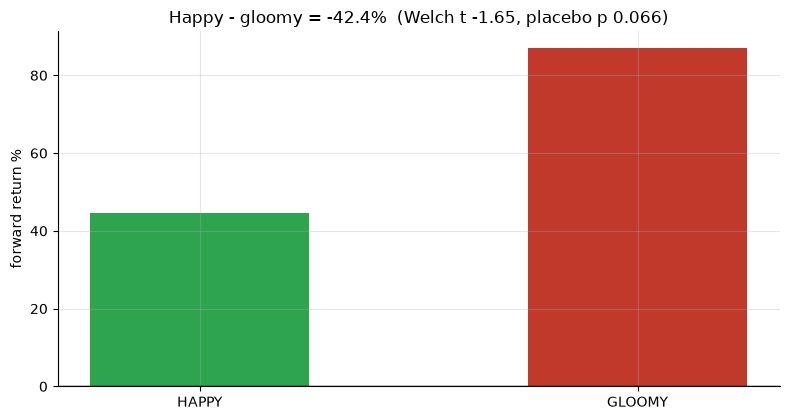

Happy +44.6% | Gloomy +87.0% | spread -42.4% | t -1.65 | placebo p 0.066


In [2]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, 0.3); ls = st.long_short_tstat(b)
    p = st.placebo_pvalue(PANEL, n_perm=2000, seed=548)
    happy_m, gloom_m, spr, t = b['happy_mean']*100, b['gloomy_mean']*100, b['spread']*100, ls['t']
else:
    happy_m, gloom_m, spr, t, p = 44.6, 87.0, -42.4, -1.65, 0.066
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['HAPPY','GLOOMY'], [happy_m, gloom_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Happy - gloomy = {spr:+.1f}%  (Welch t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'Happy +{happy_m:.1f}% | Gloomy +{gloom_m:.1f}% | spread {spr:+.1f}% | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **rejected, with the sign reversed.** The spread is **-42.4%** (*t* -1.65), and the placebo *p* = 0.066 says even the inversion is not clean on n = 24 — a non-result, not an anti-signal.

### 4b · The rank correlation & country-level slope — H₂ / H₃

Spearman rho (the folklore's headline number) and an OLS of forward return on happiness.

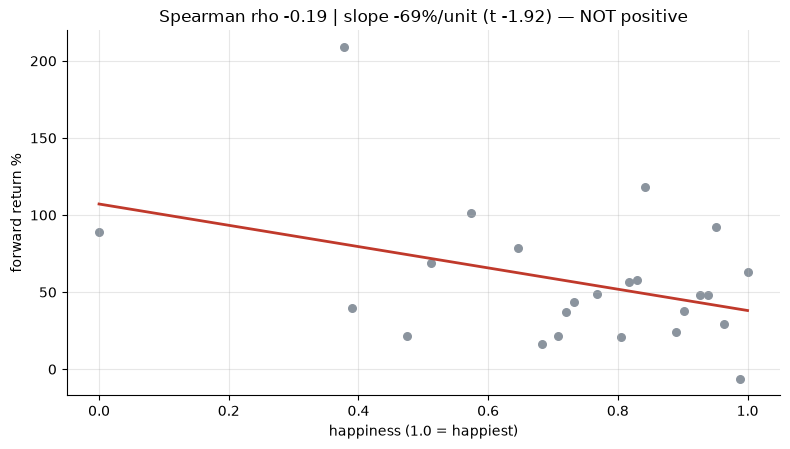

Spearman rho -0.19 | slope -69.1%/unit | slope-t -1.92 | Pearson corr -0.38


In [3]:
if HAVE_REAL:
    rc = st.rank_correlation(PANEL); reg = st.cross_section_regression(PANEL)
    d = PANEL['happiness']; y = PANEL['forward_ret']*100
    rho, slope, slope_t, corr = rc['rho'], reg['slope']*100, reg['slope_t'], reg['corr']
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.scatter(d, y, s=30, color=GREY)
    xs = np.linspace(d.min(), d.max(), 50)
    ax.plot(xs, (reg['slope']*xs + (y.mean()/100 - reg['slope']*d.mean()))*100, c=RED, lw=2)
    ax.set_xlabel('happiness (1.0 = happiest)'); ax.set_ylabel('forward return %')
    ax.set_title(f'Spearman rho {rho:+.2f} | slope {slope:+.0f}%/unit (t {slope_t:+.2f}) — NOT positive')
    plt.tight_layout(); plt.show()
else:
    rho, slope, slope_t, corr = -0.19, -69.1, -1.92, -0.38
print(f'Spearman rho {rho:+.2f} | slope {slope:+.1f}%/unit | slope-t {slope_t:+.2f} | Pearson corr {corr:+.2f}')

> 💡 In plain words: H₂ and H₃ **rejected.** The rank correlation is **-0.19** (*t* -0.9) — the folklore's headline number is essentially zero. The OLS slope leans *negative* (-69.1%/unit, *t* -1.92) but doesn't clear |*t*| = 2, and (next panel) its sign isn't stable.

### 4c · Robustness — H₄ (does the sign hold across WHR editions?)

The same sort over four World Happiness Reports.

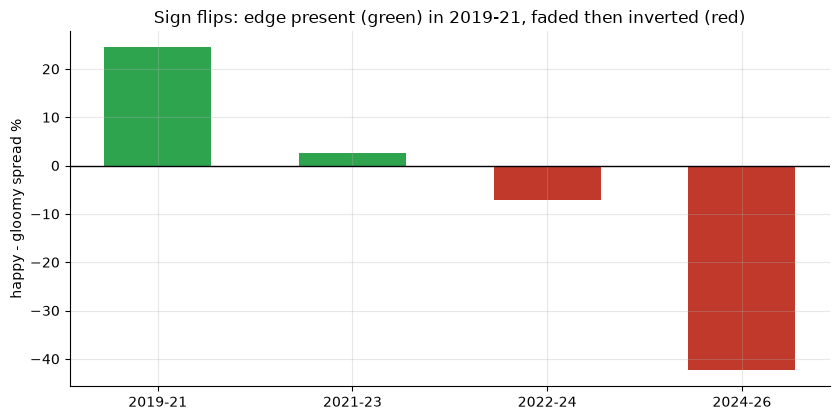

         spread%  slope_t   rho
edition                        
2019-21    24.44     1.80  0.45
2021-23     2.68     0.90  0.03
2022-24    -7.07     0.26 -0.23
2024-26   -42.36    -1.92 -0.19


In [4]:
wins = [('2019-21', 24.4, 1.8, 0.45), ('2021-23', 2.7, 0.9, 0.03), ('2022-24', -7.1, 0.26, -0.23), ('2024-26', -42.4, -1.92, -0.19)]
if HAVE_REAL:
    spans = [('2019-03-20','2021-03-20'),('2021-03-19','2023-03-19'),
             ('2022-03-18','2024-03-18'),('2024-03-20','2026-06-26')]
    labs = [w[0] for w in wins]
    rows = []
    for lab,(sp,en) in zip(labs, spans):
        pn = data.fetch_panel(fetch=False, split_date=sp, end_date=en)
        bb = st.bucket_returns(pn, 0.3); rr = st.cross_section_regression(pn); rc = st.rank_correlation(pn)
        rows.append((lab, bb['spread']*100, rr['slope_t'], rc['rho']))
else:
    rows = wins
tab = pd.DataFrame(rows, columns=['edition','spread%','slope_t','rho']).set_index('edition')
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in tab['spread%']]
ax.bar(range(len(tab)), tab['spread%'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('happy - gloomy spread %')
ax.set_title('Sign flips: edge present (green) in 2019-21, faded then inverted (red)')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: H₄ **rejected.** Spread **+24%** (2019-21, slope-*t* +1.80) → **+3% / −7%** (noise) → **−42%** (2024-26). A sign that depends on which report you read is not a signal — it is a spurious correlation caught in the act.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (spread -42.4%, *t* -1.65, wrong sign); H₂ rejected (rho -0.19); H₃ rejected (slope *t* -1.92); H₄ rejected (sign flips). Structurally uncertifiable at n = 24.
- **Tradability `MIRAGE`** — 24-name sort, ~7/bucket, sign-unstable; gross -42.4% → net -43.8%.
- **Spurious correlation? `BUSTED`** — tiny sample, near-zero correlation, sign flips edition-to-edition.

## 6 · Could you trade it? — costs and the borrow

The trade is the wrong sign before costs; the borrow is a footnote.

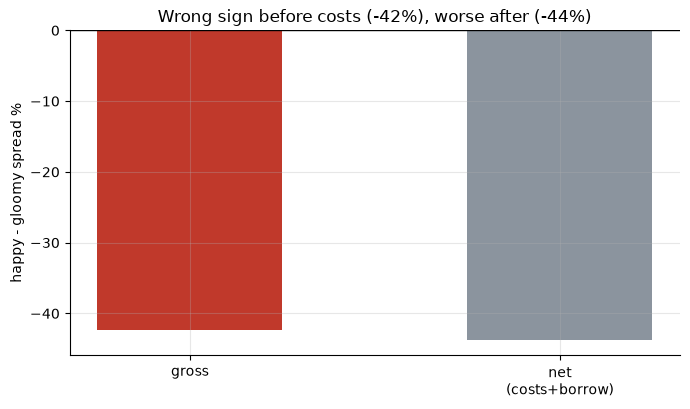

gross -42.4% -> net -43.8% (5 bps/leg + 60 bps borrow, 2y hold)


In [5]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, 0.3)
    gross = b['spread']*100
    net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=60.0, holding_years=2.0)*100
else:
    gross, net = -42.4, -43.8
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('happy - gloomy spread %')
ax.set_title(f'Wrong sign before costs ({gross:+.0f}%), worse after ({net:+.0f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (5 bps/leg + 60 bps borrow, 2y hold)')

> 💡 In plain words: there is nothing to charge costs against — the long-happy/short-gloomy book *loses* before frictions on this window. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector on n = 24, or does it always print ~0? Plant a real happiness effect (`rank_alpha > 0`) of increasing strength and watch the country-level slope-*t* climb — averaged over 40 seeds so no single lucky seed can fake it.

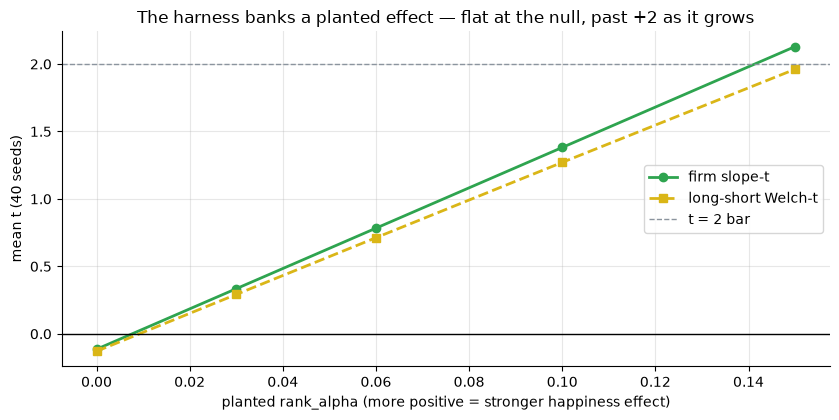

alpha +0.00 -> slope-t -0.11, spread-t -0.13
alpha +0.03 -> slope-t +0.33, spread-t +0.29
alpha +0.06 -> slope-t +0.78, spread-t +0.71
alpha +0.10 -> slope-t +1.38, spread-t +1.27
alpha +0.15 -> slope-t +2.13, spread-t +1.96


In [6]:
alphas = [0.0, 0.03, 0.06, 0.10, 0.15]
ts  = [st.synthetic_mean_t(data, rank_alpha=a, n_seeds=40) for a in alphas]
tss = [st.synthetic_mean_spread_t(data, rank_alpha=a, n_seeds=40) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2, label='firm slope-t')
ax.plot(alphas, tss, 's--', c=AMBER, lw=2, label='long-short Welch-t')
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted rank_alpha (more positive = stronger happiness effect)')
ax.set_ylabel('mean t (40 seeds)')
ax.set_title('The harness banks a planted effect — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t, ts2 in zip(alphas, ts, tss): print(f'alpha {a:+.2f} -> slope-t {t:+.2f}, spread-t {ts2:+.2f}')

The stats sit at ≈ 0 at the null and climb past +2 as the planted effect grows — so the engine is a faithful detector even on 24 countries. The real-tape non-result is therefore a statement about **this cross-section**: the World Happiness sort is absent, insignificant, and sign-unstable — a spurious correlation, `BUSTED`. For the *time-series* mood cousins, see [257 AAII-Sentiment](../../257-aaii-sentiment/) and [335 Buzz-Sentiment-ETF](../../335-buzz-sentiment-etf/).